# Tutorial 8: Photometric Calibration

This tutorial demonstrates how to compute and apply **photometric offsets**
using brutus. Photometric offsets are multiplicative corrections that account
for systematic differences between observed fluxes and model predictions,
arising from filter profile differences, calibration systematics, and
atmospheric model limitations.

## Topics Covered

1. **Model grids and SED generation**: the magnitude coefficient format
2. **Synthetic observations**: generating test data with known offsets
3. **`PhotometricOffsetsConfig`**: configuring the offset computation
4. **`photometric_offsets()`**: recovering offsets from posterior samples

## Prerequisites

This tutorial requires the grid data file `grid_mist_v9.h5` (downloaded
automatically via Pooch on first use).

In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Tutorial utilities
from tutorial_utils import (
    set_plot_style,
    find_brutus_data_file,
    save_figure as save_fig_util,
    print_section
)

# brutus imports
from brutus.data import load_models
from brutus.core import get_seds
from brutus.analysis import photometric_offsets, PhotometricOffsetsConfig

set_plot_style()
plt.rcParams['figure.figsize'] = (12, 5)

plots_dir = Path('plots/tutorial_08')
plots_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    filepath = plots_dir / f"{name}.png"
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filepath}")

## Section 1: Model Grid and SED Computation

The `photometric_offsets()` function operates on the same model grid used by
`BruteForce`. Each model is stored as magnitude polynomial coefficients with
shape `(n_filters, 3)`:

| Index | Quantity | Description |
|-------|----------|-------------|
| 0 | mag_0 | Unreddened apparent magnitude (at reference distance) |
| 1 | R_0 | Reddening coefficient at R(V) = 0 |
| 2 | dR/dR_V | Change in reddening coefficient with R(V) |

The reddened magnitude in a given band is:

    m(band) = mag_0(band) + A_V * [R_0(band) + R_V * dR(band)]

The `get_seds()` function applies this formula and optionally converts
magnitudes to linear flux densities. Combined with distance scaling
(F proportional to d^-2), this produces the model photometry that
`photometric_offsets()` compares against observations.

In [2]:
# Load the stellar model grid with PS1 + 2MASS filters
print_section("Loading Model Grid")

grid_file = find_brutus_data_file('grid_mist_v9.h5')

# Select the standard PS1 + 2MASS photometric system (8 filters)
filter_names = ['PS_g', 'PS_r', 'PS_i', 'PS_z', 'PS_y',
                '2MASS_J', '2MASS_H', '2MASS_Ks']
short_names = ['g', 'r', 'i', 'z', 'y', 'J', 'H', 'Ks']

models, labels, label_mask = load_models(grid_file, filters=filter_names)

n_models, n_filt, n_coeff = models.shape
print(f"Grid shape: {models.shape}")
print(f"  {n_models:,} models x {n_filt} filters x {n_coeff} coefficients")
print(f"  Filters: {', '.join(short_names)}")
print(f"\nCoefficient structure per model per filter:")
print(f"  [0] mag_0  : unreddened magnitude at reference distance")
print(f"  [1] R_0    : reddening coefficient (at R_V = 0)")
print(f"  [2] dR/dR_V: change in reddening with R(V)")

# Demonstrate SED generation for a single model
example_idx = n_models // 2
seds_mag = get_seds(models[example_idx:example_idx+1],
                    av=np.array([0.5]), rv=np.array([3.3]),
                    return_flux=False)
seds_flux = get_seds(models[example_idx:example_idx+1],
                     av=np.array([0.5]), rv=np.array([3.3]),
                     return_flux=True)

print(f"\nExample SED (model {example_idx}, A_V=0.5, R_V=3.3):")
for i in range(n_filt):
    print(f"  {short_names[i]:>2s}: mag = {seds_mag[0, i]:.3f},  "
          f"flux = {seds_flux[0, i]:.4e}")


Loading Model Grid


Reading entire dataset (49 filters) once...


Extracting 8 requested filters from memory...


Grid shape: (613530, 8, 3)
  613,530 models x 8 filters x 3 coefficients
  Filters: g, r, i, z, y, J, H, Ks

Coefficient structure per model per filter:
  [0] mag_0  : unreddened magnitude at reference distance
  [1] R_0    : reddening coefficient (at R_V = 0)
  [2] dR/dR_V: change in reddening with R(V)

Example SED (model 306765, A_V=0.5, R_V=3.3):
   g: mag = 8.616,  flux = 3.5792e-04
   r: mag = 7.445,  flux = 1.0517e-03
   i: mag = 6.888,  flux = 1.7567e-03
   z: mag = 6.601,  flux = 2.2896e-03
   y: mag = 6.441,  flux = 2.6512e-03
   J: mag = 5.210,  flux = 8.2414e-03
   H: mag = 4.368,  flux = 1.7902e-02
  Ks: mag = 4.224,  flux = 2.0436e-02


## Section 2: Generating Synthetic Observations with Known Offsets

To demonstrate offset recovery, we create a controlled experiment:

1. **Select random stellar models** from the grid with realistic parameters
2. **Compute true photometry** using `get_seds()` with distance scaling
3. **Apply known multiplicative offsets** to simulate calibration systematics
4. **Add photometric noise** to simulate realistic observations

The `photometric_offsets()` function returns **multiplicative correction
factors** (model / observed), so if we apply an offset of 1.05 to the data
(making it 5% brighter), the recovered correction should be 1/1.05 = 0.952
to bring it back to the model prediction.

In [3]:
# Generate synthetic observations with known offsets
print_section("Generating Synthetic Observations")

rng = np.random.default_rng(42)
n_obj = 200

# Select random models and physical parameters
true_idxs = rng.integers(0, n_models, n_obj)
true_av = rng.uniform(0.0, 1.5, n_obj)
true_rv = rng.uniform(2.8, 3.8, n_obj)
true_dist = rng.uniform(0.5, 5.0, n_obj)  # kpc

# Generate true photometry using get_seds()
true_flux = get_seds(models[true_idxs], av=true_av, rv=true_rv,
                     return_flux=True)
true_flux /= true_dist[:, None]**2  # Scale by distance

# Define known multiplicative offsets per filter
# Values > 1: observed brighter than model; < 1: observed fainter
applied_offsets = np.array([1.04, 0.97, 1.01, 0.98, 1.03, 0.99, 1.02, 0.96])

# Expected corrections: photometric_offsets returns model/observed
expected_corrections = 1.0 / applied_offsets

# Apply offsets and add noise
observed_flux = true_flux * applied_offsets[None, :]
flux_err = 0.03 * np.abs(observed_flux)  # 3% photometric errors
observed_flux = observed_flux + rng.normal(0, flux_err)
observed_flux = np.maximum(observed_flux, 1e-10)  # Ensure positive

# Observation mask: all bands observed
mask = np.ones((n_obj, n_filt), dtype=int)

print(f"Generated {n_obj} synthetic stars across {n_filt} filters")
print(f"Photometric noise: ~3% per band")
print(f"\nApplied multiplicative offsets:")
for i in range(n_filt):
    sign = "+" if applied_offsets[i] > 1 else ""
    pct = (applied_offsets[i] - 1) * 100
    print(f"  {short_names[i]:>2s}: {applied_offsets[i]:.3f}  ({sign}{pct:.1f}%)")


Generating Synthetic Observations
Generated 200 synthetic stars across 8 filters
Photometric noise: ~3% per band

Applied multiplicative offsets:
   g: 1.040  (+4.0%)
   r: 0.970  (-3.0%)
   i: 1.010  (+1.0%)
   z: 0.980  (-2.0%)
   y: 1.030  (+3.0%)
   J: 0.990  (-1.0%)
   H: 1.020  (+2.0%)
  Ks: 0.960  (-4.0%)


## Section 3: Computing Photometric Offsets

The `photometric_offsets()` function requires **posterior samples** from
fitting: model indices, extinction, reddening shape, and distances for each
star. In practice these come from `BruteForce.fit()` output. For this
demonstration, we construct synthetic posteriors by perturbing the known
true parameters with small Gaussian scatter.

### PhotometricOffsetsConfig

The `PhotometricOffsetsConfig` class controls the offset computation:

| Parameter | Default | Description |
|---|---|---|
| `n_bootstrap` | 300 | Bootstrap realizations for uncertainty |
| `min_bands_used` | 4 | Minimum observed bands for reweighted filters |
| `min_bands_unused` | 3 | Minimum observed bands for non-reweighted filters |
| `uncertainty_method` | `'bootstrap_iqr'` | `'bootstrap_iqr'` (robust) or `'bootstrap_std'` |
| `random_seed` | None | Seed for reproducibility |

### Likelihood Reweighting

An important feature (not demonstrated here) is the `mask_fit` parameter.
When a band was used in the original `BruteForce` fit, the posterior samples
are biased toward models that fit that band well. Setting `mask_fit[i] = True`
triggers leave-one-out reweighting that recomputes the likelihood **excluding**
that band to avoid circular bias. This is critical for real fitting results
but not needed for our synthetic posteriors, which are unbiased by construction.

In [4]:
# Create synthetic posterior samples and compute offsets
print_section("Computing Photometric Offsets")

# --- Step 1: Create synthetic posterior samples ---
# In practice, these come from BruteForce.fit() output arrays:
#   model_idx  -> idxs    (n_obj, n_samples)
#   samps_red  -> reds    (n_obj, n_samples)
#   samps_dred -> dreds   (n_obj, n_samples)
#   samps_dist -> dists   (n_obj, n_samples)

n_samp = 25  # posterior samples per star

# Perturb true parameters to simulate posterior uncertainty
idxs = np.tile(true_idxs[:, None], (1, n_samp))
reds = np.clip(rng.normal(true_av[:, None], 0.05, (n_obj, n_samp)), 0.0, 5.0)
dreds = np.clip(rng.normal(true_rv[:, None], 0.05, (n_obj, n_samp)), 2.0, 5.0)
dists = np.clip(rng.normal(true_dist[:, None], 0.1, (n_obj, n_samp)), 0.1, 20.0)

print(f"Posterior samples: {n_obj} objects x {n_samp} samples")
print(f"  A_V perturbation:  sigma ~ 0.05 mag")
print(f"  R_V perturbation:  sigma ~ 0.05")
print(f"  Dist perturbation: sigma ~ 0.1 kpc")

# --- Step 2: Configure offset computation ---
config = PhotometricOffsetsConfig(
    n_bootstrap=300,
    min_bands_used=3,
    min_bands_unused=2,
    uncertainty_method='bootstrap_iqr',
    random_seed=42,
    progress_interval=0,
)

# --- Step 3: Run photometric_offsets ---
# mask_fit=False for all bands: uniform weights (no reweighting needed
# since synthetic posteriors are unbiased by construction)
offsets, errors, n_used = photometric_offsets(
    observed_flux, flux_err, mask,
    models, idxs, reds, dreds, dists,
    mask_fit=np.zeros(n_filt, dtype=bool),
    config=config,
    verbose=True,
)

# --- Step 4: Report results ---
print(f"\n{'Band':>6}  {'Applied':>8}  {'Expected':>9}  {'Recovered':>10}  "
      f"{'Error':>7}  {'N_used':>7}")
print("  " + "-" * 56)
for i in range(n_filt):
    print(f"  {short_names[i]:>4s}  {applied_offsets[i]:>8.4f}  "
          f"{expected_corrections[i]:>9.4f}  {offsets[i]:>10.4f}  "
          f"{errors[i]:>7.4f}  {n_used[i]:>7d}")

residuals = offsets - expected_corrections
rms = np.sqrt(np.mean(residuals**2))
max_err = np.max(np.abs(residuals))
print(f"\nRecovery statistics:")
print(f"  RMS residual:     {rms:.4f} ({rms*100:.2f}%)")
print(f"  Max |residual|:   {max_err:.4f} ({max_err*100:.2f}%)")
print(f"  Mean uncertainty: {np.mean(errors):.4f} ({np.mean(errors)*100:.2f}%)")


Computing Photometric Offsets
Posterior samples: 200 objects x 25 samples
  A_V perturbation:  sigma ~ 0.05 mag
  R_V perturbation:  sigma ~ 0.05
  Dist perturbation: sigma ~ 0.1 kpc


Photometric offset computation complete.

  Band   Applied   Expected   Recovered    Error   N_used
  --------------------------------------------------------
     g    1.0400     0.9615      0.9635   0.0081      200
     r    0.9700     1.0309      1.0381   0.0096      200
     i    1.0100     0.9901      0.9894   0.0077      200
     z    0.9800     1.0204      1.0180   0.0083      200
     y    1.0300     0.9709      0.9694   0.0067      200
     J    0.9900     1.0101      1.0094   0.0078      200
     H    1.0200     0.9804      0.9825   0.0072      200
    Ks    0.9600     1.0417      1.0450   0.0069      200

Recovery statistics:
  RMS residual:     0.0031 (0.31%)
  Max |residual|:   0.0071 (0.71%)
  Mean uncertainty: 0.0078 (0.78%)


  Saved: plots/tutorial_08/offset_recovery.png


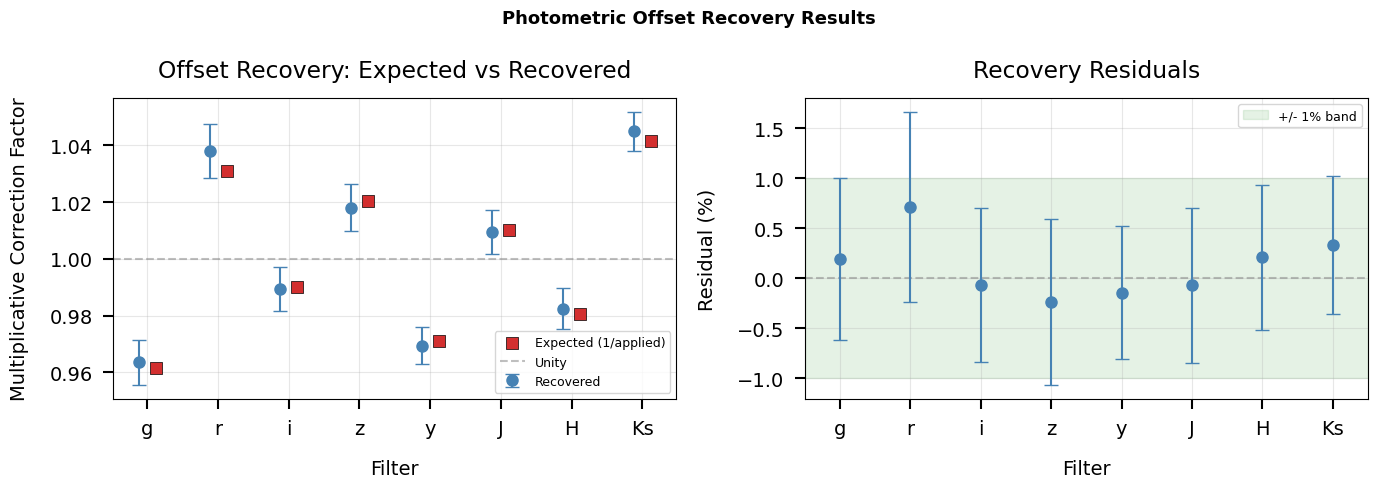


All 8 offsets recovered; RMS residual = 0.31%


In [5]:
# Visualize offset recovery
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(n_filt)

# Left: recovered vs expected
ax = axes[0]
ax.errorbar(x - 0.12, offsets, yerr=errors, fmt='o', capsize=5,
            color='steelblue', markersize=8, label='Recovered', zorder=5)
ax.scatter(x + 0.12, expected_corrections, marker='s', s=80,
           color='#d32f2f', edgecolor='k', linewidth=0.5,
           label='Expected (1/applied)', zorder=5)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Unity')
ax.set_xlabel('Filter')
ax.set_ylabel('Multiplicative Correction Factor')
ax.set_title('Offset Recovery: Expected vs Recovered')
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: residuals
ax = axes[1]
ax.errorbar(x, residuals * 100, yerr=errors * 100, fmt='o', capsize=5,
            color='steelblue', markersize=8, zorder=5)
ax.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between([-0.5, n_filt - 0.5], -1, 1, alpha=0.1, color='green',
                label='+/- 1% band')
ax.set_xlabel('Filter')
ax.set_ylabel('Residual (%)')
ax.set_title('Recovery Residuals')
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_xlim(-0.5, n_filt - 0.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Photometric Offset Recovery Results', fontsize=13,
             fontweight='bold')
plt.tight_layout()
save_figure(fig, 'offset_recovery')
plt.show()

print(f"\nAll {n_filt} offsets recovered; RMS residual = {rms*100:.2f}%")

## Summary

This tutorial demonstrated the complete workflow for computing photometric
offsets with brutus.

### Key Concepts

1. **Photometric offsets are multiplicative**: `corrected_flux = observed_flux * offset`
2. **Model SED computation**: `get_seds()` applies extinction and converts to flux
3. **Posterior samples required**: offsets use `(idxs, reds, dreds, dists)` from fitting
4. **Bootstrap uncertainty**: robust estimation via bootstrap median with IQR

### The `photometric_offsets()` Algorithm

1. Generate model SEDs for all posterior samples via `get_seds()`
2. Scale by inverse distance squared: F_model proportional to d^{-2}
3. Compute flux ratios: ratio = model / observed per band
4. For fitted bands: reweight samples via leave-one-out likelihood
5. Bootstrap the median ratio to get offset +/- uncertainty per filter

### Practical Usage

In a real analysis pipeline:

```python
# After BruteForce fitting
offsets, errors, n_used = photometric_offsets(
    phot, err, mask,                      # observed data
    models, idxs, reds, dreds, dists,     # models + fit results
    mask_fit=mask_fit,                    # which bands were fitted
    config=PhotometricOffsetsConfig(),    # configuration
)
phot_corrected = phot * offsets[None, :]  # apply corrections
```

### Next Steps

- **Tutorial 9**: Utility functions for photometry conversions and likelihoods
- **Tutorial 10**: Plotting functions for visualizing fitting results
- **Tutorial 11**: Working with BruteForce output files

In [6]:
print("Tutorial 8 Complete!")
print("=" * 60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")
print(f"\nOffset recovery ({n_filt} filters): RMS residual = {rms*100:.2f}%")
print(f"Bootstrap uncertainty: mean = {np.mean(errors)*100:.2f}%")
print(f"Objects used per filter: {n_used.min()}-{n_used.max()} of {n_obj}")

Tutorial 8 Complete!

Generated plots:
  - offset_recovery.png

Offset recovery (8 filters): RMS residual = 0.31%
Bootstrap uncertainty: mean = 0.78%
Objects used per filter: 200-200 of 200
